# Blueberry epicuticular wax (EW) loss — NIR hyperspectral pixel classification (BB-HSI dataset)

**Paper:** Faisal, S.; Thawdar, Y.; Ooi, M. P.-L.; Reutemann, P.; Fletcher, D.; Kuang, Y. C.; Abeysekera, S. K.
*Proximal near-infrared hyperspectral imaging dataset for identifying epicuticular wax loss in Masena blueberries to evaluate post-harvest quality.*
**Data in Brief 62:111946 (2025)** — [doi:10.1016/j.dib.2025.111946](https://doi.org/10.1016/j.dib.2025.111946) · [PMC12356377](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC12356377/)

**Dataset:** [BB-HSI, Harvard Dataverse doi:10.7910/DVN/ENJYTC](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/ENJYTC) (v1, 2025-05-15, **CC0 1.0**).
**Author tooling:** [wairas/happy-tools](https://github.com/wairas/happy-tools) @ `b4476d01f19533d4e2bedf28bb781c4fb0d150e2` (MIT).

## Purpose and scope

This paper is a **data release** (49 hyperspectral images of 39 'Masena' blueberries, Specim FX17e,
900–1700 nm, 224 bands; white/dark-reference-normalized `normcube` + annotated `FinalMask` in MATLAB `.mat`
files). It reports no classification pipeline, so this notebook reproduces the **minimal runnable analysis**
the data supports end to end, on **one scan**:

- Load the `'No EW vs. Perfect EW'` hypercube (`10BloomVsNoBloomB_2023-11-24_01-33-21.1.mat`,
  600,489,584 bytes, MD5 verified) following the author's `MatlabReader` key mapping
  (`normcube` = 1046×640×224 spectra, `FinalMask` = 1046×640 labels, `lambda` = wavelengths).
- Preview the input with the **author's reference annotation** (`FinalMask`: 0 unlabeled, 1 background,
  2 bloom/EW present, 3 no bloom/EW absent, 4 white reference — paper Table 2, cross-checked against the
  dataset's own `mask.json`).
- Sample a bounded, seeded subset of pixel spectra (author `ps-simple` selector semantics), plot mean ± SD
  bloom vs no-bloom reflectance, train one scikit-learn classifier from the author's
  `CLASSIFICATION_MODEL_MAP` (`randomforestclassifier`), and evaluate pixel-level classification plus a
  full-mask prediction map vs the reference annotation.

**Execution status — ADAPTED PYTHON DEMONSTRATION.** ⚠️ The authors did not provide this Colab
implementation. It is an AI-assisted adaptation that follows the pinned happy-tools code (reader key
mapping, bounded pixel selector, sklearn model map; cited per cell). The executed example and checks below
were validated on a fresh Google Colab **CPU** runtime; untested behavior is not guaranteed. A pixel-level
train/test split on one scan (adjacent-pixel leakage) is optimistic and **does not** verify any
dataset-level accuracy from the paper (the paper reports none).

**日本語の概要:** 本論文はデータセット公開論文であり、分類手法の実装は含まれていません。このノートブックは、
公開データ(CB0)のハイパースペクトル画像1枚(No EW vs Perfect EW)を著者ツール happy-tools の読み込み規約に
従って読み込み、FinalMask ラベル 2(bloom)/3(no bloom)の画素スペクトルを少数サンプリングして
scikit-learn のランダムフォレストで画素レベル分類を行う**最小デモ**です。著者提供の Colab 実装ではなく
AI による翻案(ADAPTED PYTHON DEMONSTRATION)であり、結果は論文の精度検証ではありません。

**References used as evidence (this notebook's provenance):** paper Sections 3–4 (via PMCID PMC12356377),
happy-tools @ `b4476d01…` files `src/happy/readers/_matlab_reader.py`, `src/happy/pixel_selectors/_simple_selector.py`,
`src/happy/models/sklearn.py`, `src/happy/console/builders/segmentation_build.py`, and Dataverse record metadata.

## 1. Runtime selection — CPU is enough

**Select `ランタイム` → `ランタイムのタイプを変更` → `CPU` (standard, free tier is sufficient), then `ランタイム` → `すべてのセルを実行` (Run all).**

No GPU is used anywhere: the method is a classical scikit-learn classifier on a few ten-thousand 224-band
spectra, and the author pipeline is sklearn-based. Expected wall time (estimate, not measurement):
~2–5 min download (600 MB) + ~2–4 min processing ⇒ **~10 minutes end to end**; downloads ≈ 600 MB to the
Colab VM scratch disk (`/content`, not your Drive). Measured times are printed by the cells.

**日本語:** GPU は不要です(CPU で十分)。すべてのセルを実行すると約 10 分、ダウンロード約 600 MB(Colab の
一時ディスクのみ、Drive 不要)の見込みです。実測値はセル出力に表示されます。

In [ ]:
# Minimal scientific stack check. scipy / scikit-learn / pandas / matplotlib are preinstalled on
# current Colab CPU runtimes; this cell only installs anything missing (h5py is only needed for the
# MATLAB v7.3 fallback). Nothing is built from source.
import importlib, subprocess, sys

for pkg, mod in [("scipy", "scipy"), ("scikit-learn", "sklearn"),
                 ("matplotlib", "matplotlib"), ("pandas", "pandas"), ("h5py", "h5py")]:
    try:
        importlib.import_module(mod)
    except ModuleNotFoundError:
        print(f"installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy, scipy, sklearn, matplotlib, pandas
print("python  :", sys.version.split()[0])
print("numpy   :", numpy.__version__)
print("scipy   :", scipy.__version__)
print("sklearn :", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas  :", pandas.__version__)

python  : 3.13.16
numpy   : 2.1.3
scipy   : 1.16.3
sklearn : 1.6.1
matplotlib: 3.10.0
pandas  : 2.2.3


## 2. Input acquisition (inside Colab, verified bytes)

Downloaded from the paper-linked Harvard Dataverse record **doi:10.7910/DVN/ENJYTC** (v1, CC0 1.0,
`restricted=false`) via the documented public file API `GET /api/access/datafile/{fileId}`:

| file | id | bytes | MD5 |
|---|---|---|---|
| `10BloomVsNoBloomB_2023-11-24_01-33-21.1.mat` ('No EW vs. Perfect EW' scan) | 11382703 | 600,489,584 | `36c37fad5758833b21fa6a75962e2a16` |
| `mask.json` (label definitions supplement) | 11382699 | 97 | `787d293a63fb0a667d52c27cf4443f12` |

(Metadata source: Dataverse record API v1, checked 2026-10-08.) Both files land under `/content/bbhsi/`
on the Colab VM; MD5 and byte size are asserted before any scientific use. Bounded retries; `429` honors
`Retry-After`.

**日本語:** 論文がリンクする Harvard Dataverse(CB0 ライセンス)から公開ファイル API で 2 ファイルのみ取得し、
バイト数と MD5 を検証してから使います。ファイルは Colab VM の `/content` に置かれます。

In [ ]:
import hashlib, os, time
from pathlib import Path
import requests

DATA_DIR = Path("/content/bbhsi")
DATA_DIR.mkdir(parents=True, exist_ok=True)

MAT_URL = "https://dataverse.harvard.edu/api/access/datafile/11382703"
MASK_URL = "https://dataverse.harvard.edu/api/access/datafile/11382699"
MAT_PATH = DATA_DIR / "10BloomVsNoBloomB_2023-11-24_01-33-21.1.mat"
MASK_PATH = DATA_DIR / "mask.json"
MAT_MD5 = "36c37fad5758833b21fa6a75962e2a16"
MAT_SIZE = 600489584
MASK_MD5 = "787d293a63fb0a667d52c27cf4443f12"
MASK_SIZE = 97


def dataverse_download(url: str, dest: Path, expected_md5: str, expected_size: int,
                       max_attempts: int = 3) -> None:
    """Stream a public Dataverse datafile with bounded retries; assert size + MD5 afterwards."""
    for attempt in range(1, max_attempts + 1):
        try:
            t0 = time.time()
            with requests.get(url, stream=True, timeout=(15, 900)) as r:
                r.raise_for_status()
                got = 0
                with open(dest, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                        f.write(chunk)
                        got += len(chunk)
                        if got // (100 * 1024 * 1024) != (got - len(chunk)) // (100 * 1024 * 1024):
                            print(f"  {got/1e6:8.1f} MB ...", flush=True)
            break
        except requests.RequestException as e:
            if attempt == max_attempts:
                raise RuntimeError(f"download failed after {max_attempts} attempts: {e}") from e
            retry_after = getattr(getattr(e, "response", None), "headers", {}).get("Retry-After")
            wait = int(retry_after) if (retry_after or "").isdigit() else 10 * attempt
            print(f"attempt {attempt} failed ({e}); retrying in {wait}s", flush=True)
            time.sleep(min(wait, 60))
    h = hashlib.md5()  # hash the finished file in blocks (works for any size)
    with open(dest, "rb") as f:
        for block in iter(lambda: f.read(16 * 1024 * 1024), b""):
            h.update(block)
    digest = h.hexdigest()
    if dest.stat().st_size != expected_size or digest != expected_md5:
        raise RuntimeError(f"checksum mismatch for {dest.name}: "
                           f"size {dest.stat().st_size} (expected {expected_size}), md5 {digest} (expected {expected_md5})")
    print(f"OK {dest.name}: {dest.stat().st_size:,} bytes, md5 {digest}, {time.time()-t0:.1f}s")


print("downloading mask.json ...", flush=True)
dataverse_download(MASK_URL, MASK_PATH, MASK_MD5, MASK_SIZE)
print("downloading the 600 MB hypercube (one scan) ...", flush=True)
t_mat = time.time()
dataverse_download(MAT_URL, MAT_PATH, MAT_MD5, MAT_SIZE)
MAT_DL_S = time.time() - t_mat
print(f"download wall time: {MAT_DL_S:.1f}s")

downloading mask.json ...


OK mask.json: 97 bytes, md5 787d293a63fb0a667d52c27cf4443f12, 0.5s
downloading the 600 MB hypercube (one scan) ...


     109.1 MB ...


     209.7 MB ...


     318.8 MB ...


     419.4 MB ...


     528.5 MB ...


OK 10BloomVsNoBloomB_2023-11-24_01-33-21.1.mat: 600,489,584 bytes, md5 36c37fad5758833b21fa6a75962e2a16, 12.5s
download wall time: 12.5s


## 3. Load and validate the hypercube (author `MatlabReader` mapping)

happy-tools' `MatlabReader` (`src/happy/readers/_matlab_reader.py` @ `b4476d01…`) defines the `.mat`
contract: `normcube` = spectral data (H×W×bands), `lambda` = wavelengths, `FinalMask` = pixel annotation
mask, optional `FinalMaskLabels` = pixel-index→label table. Per the paper (Table 1) this file should hold a
**1046×640×224** `normcube` and a **1046×640** `FinalMask`. The cell asserts these **after** parsing —
including the dataset's known `lambda` dimension inconsistency (paper Table 1 says 24×7, its text says
224×7): whatever the stored shape, it is flattened and checked against the actual band count, falling back
to band indices with a loud warning if that fails. A MATLAB v7.3 (HDF5) variant is handled by an `h5py`
fallback (arrays transposed from MATLAB's column-major storage).

**日本語:** 著者ツール `MatlabReader` と同じキー規約で `.mat` を読み込み、形状(1046×640×224 / 1046×640)を
検証します。論文で不統一な `lambda` 次元は、実際のデータから 224 バンドへ平坦化して確認し、失敗時は
バンド番号にフォールバックして警告します。MATLAB v7.3 の場合は h5py 経由で読みます。

In [ ]:
import numpy as np
import scipy.io as sio

t_load = time.time()
try:
    mat = sio.loadmat(MAT_PATH)  # MATLAB v5/v7 format
    normcube = np.asarray(mat["normcube"])
    lam_raw = mat.get("lambda")
    final_mask = np.asarray(mat["FinalMask"])
except NotImplementedError:
    # MATLAB v7.3 is HDF5; MATLAB stores arrays column-major, so axes are reversed
    import h5py
    with h5py.File(MAT_PATH, "r") as f:
        normcube = np.asarray(f["normcube"]).transpose(2, 1, 0)
        lam_raw = np.asarray(f["lambda"]) if "lambda" in f else None
        final_mask = np.asarray(f["FinalMask"]).T

if normcube.ndim != 3:
    raise RuntimeError(f"normcube is not 3-D: {normcube.shape}")
normcube = normcube.astype(np.float32, copy=False)  # keep memory bounded
N_BANDS = normcube.shape[2]

lam = np.ravel(np.asarray(lam_raw)) if lam_raw is not None else np.array([])
if lam.size == N_BANDS:
    WAVELENGTHS_NM = lam.astype(float)
    lam_note = f"lambda flattened from {np.asarray(lam_raw).shape} to {N_BANDS} band values"
else:
    WAVELENGTHS_NM = np.arange(N_BANDS, dtype=float)
    lam_note = (f"WARNING: lambda shape {np.asarray(lam_raw).shape if lam_raw is not None else None} "
                f"does not match {N_BANDS} bands; using band indices instead (paper Table 1/text inconsistency)")
if final_mask.shape != normcube.shape[:2]:
    raise RuntimeError(f"FinalMask shape {final_mask.shape} does not match normcube {normcube.shape[:2]}")

print("normcube :", normcube.shape, normcube.dtype)
print("FinalMask:", final_mask.shape, final_mask.dtype)
print(lam_note)
print("wavelength range:", WAVELENGTHS_NM.min(), "-", WAVELENGTHS_NM.max(), WAVELENGTHS_NM.__class__.__name__)
print(f"load wall time: {time.time()-t_load:.1f}s")

labels, counts = np.unique(final_mask, return_counts=True)
print("FinalMask label histogram (label: pixels):")
print(dict(zip(labels.tolist(), counts.tolist())))

normcube : (1046, 640, 224) float32
FinalMask: (1046, 640) uint8
lambda flattened from (224,) to 224 band values
wavelength range: 900.0 - 1696.43 ndarray
load wall time: 0.2s
FinalMask label histogram (label: pixels):
{0: 332119, 1: 5364, 2: 37614, 3: 49347, 4: 244996}


## 4. Mask label definitions from the dataset's own `mask.json`

The paper's Table 2 scheme is 0 unlabeled, 1 background, 2 bloom (EW present), 3 no bloom (EW absent),
4 white reference. The 97-byte supplement `mask.json` is the dataset's own label-definition file; it is
displayed verbatim and used to build the label→name mapping (falling back to the paper scheme with a
warning if it does not parse into an int→name table).

**日本語:** 論文 Table 2 のラベル定義(0 未ラベル, 1 背景, 2 bloom, 3 no bloom, 4 白基準)を、データセット
同梱の `mask.json` を表示して確認し、名前マップを作ります(解釈できない場合は論文の定義にフォールバック)。

In [ ]:
import json

print(MASK_PATH.read_text() if MASK_PATH.exists() else "missing")  # 97 bytes, verbatim
PAPER_LABELS = {0: "unlabeled", 1: "background", 2: "bloom (EW present)",
                3: "no bloom (EW absent)", 4: "white reference"}
try:
    mask_json = json.loads(MASK_PATH.read_text())
    LABEL_NAMES = {int(k): str(v) for k, v in mask_json.items()} if isinstance(mask_json, dict) else {}
    if not LABEL_NAMES:
        raise ValueError("not an int->name mapping")
    print("parsed mask.json label map:", LABEL_NAMES)
except Exception as e:
    LABEL_NAMES = dict(PAPER_LABELS)
    print(f"mask.json not parsed as an int->name table ({e}); using paper Table 2 scheme: {LABEL_NAMES}")

for lb in (2, 3):
    if lb not in LABEL_NAMES:
        raise RuntimeError(f"expected bloom-class label {lb} missing from label definitions")

{
  "0": "Unlabelled",
  "1": "Background",
  "2": "Bloom",
  "3": "NoBloom",
  "4": "whiteref"
}
parsed mask.json label map: {0: 'Unlabelled', 1: 'Background', 2: 'Bloom', 3: 'NoBloom', 4: 'whiteref'}


## 5. Input preview — mean reflectance image with the **author's reference annotation**

Before any modelling, this is the actual downloaded sample: the panel on the left is the band-mean
reflectance of the pushbroom scan (`normcube.mean(axis=2)`, 1–99th percentile contrast stretch); the panel
on the right overlays the author's `FinalMask` reference annotation (label 2 = bloom, label 3 = no bloom).
This overlay is **reference data from the dataset**, not a model output.

**日本語:** 左は入力画像(バンド平均反射率)、右は著者による参照アノテーション `FinalMask`
(2=bloom 青、3=no bloom 赤)を重ねた表示です。モデル出力ではなくデータセット同梱の参照マスクです。

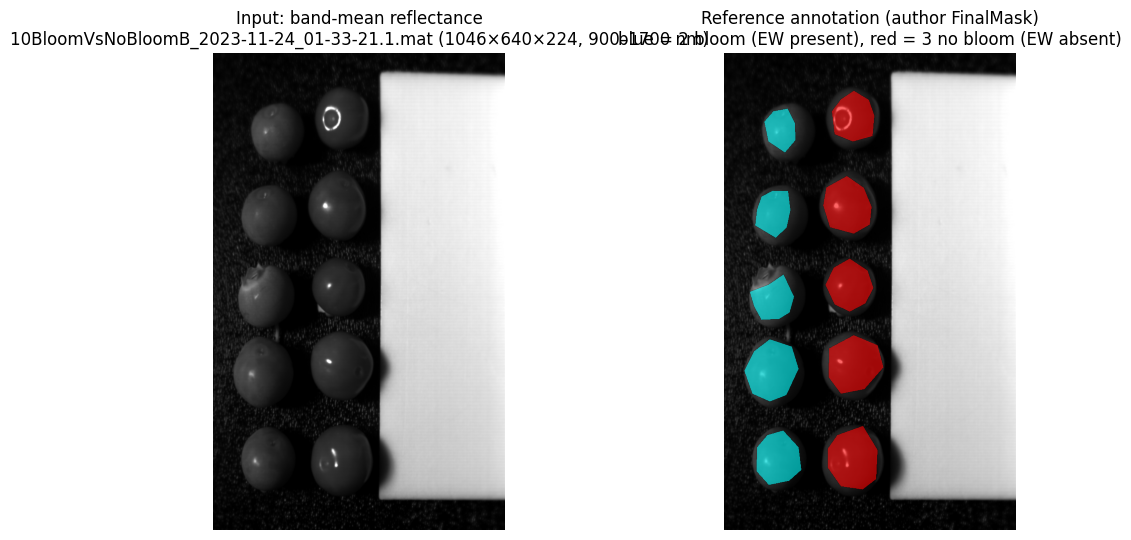

reference pixels: bloom(2)=37,614, no bloom(3)=49,347 of 669,440


In [ ]:
import matplotlib.pyplot as plt

mean_img = normcube.mean(axis=2)
lo, hi = np.percentile(mean_img, (1, 99))
img8 = np.clip((mean_img - lo) / max(hi - lo, 1e-9), 0, 1)

bloom = final_mask == 2
no_bloom = final_mask == 3

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].imshow(img8, cmap="gray")
axes[0].set_title(f"Input: band-mean reflectance\n{MAT_PATH.name} (1046×640×{N_BANDS}, 900–1700 nm)")
axes[0].set_xlabel("pixel column (pushbroom scan direction)")
axes[1].imshow(img8, cmap="gray")
axes[1].imshow(np.ma.masked_where(~bloom, bloom), cmap="cool", alpha=0.6)
axes[1].imshow(np.ma.masked_where(~no_bloom, no_bloom), cmap="autumn", alpha=0.6)
axes[1].set_title("Reference annotation (author FinalMask)\nblue = 2 bloom (EW present), red = 3 no bloom (EW absent)")
axes[1].set_xlabel("pixel column (pushbroom scan direction)")
for ax in axes:
    ax.set_axis_off()
fig.tight_layout()
plt.show()
print(f"reference pixels: bloom(2)={bloom.sum():,}, no bloom(3)={no_bloom.sum():,} of {final_mask.size:,}")

## 6. Spectral pixel sampling (author `ps-simple` selector semantics)

happy-tools' segmentation build samples training spectra with `ps-simple -n 32767` (the *simple* selector
returns the spectrum at a pixel location, bounded by `n`). Here: all pixels labeled 2 or 3 are candidates,
and a deterministic seeded sample of up to **20,000 spectra per class** is drawn (fixed seed, documented —
not a paper parameter, an adaptation). Spectra are reflectance values in the `normcube` (already
white/dark-reference normalized by the authors); units as stored (relative reflectance).

**日本語:** 著者ツールの `ps-simple` セレクタにならい、ラベル 2/3 の画素からクラスごとに最大 20,000 本の
スペクトルを固定シードで抽出します(サンプル数とシードは本デモの設定であり論文のパラメータではありません)。

In [ ]:
from numpy.random import default_rng

SEED = 42          # documented demo seed
PIX_PER_CLASS = 20000  # bounded sample, cf. happy-tools 'ps-simple -n 32767'

rng = default_rng(SEED)
mask_flat = final_mask.ravel()
X_all = normcube.reshape(-1, N_BANDS)  # view over the hypercube: (H*W, bands)

sampled_idx = []
y_list = []
for label in (2, 3):
    idx = np.flatnonzero(mask_flat == label)
    if idx.size == 0:
        raise RuntimeError(f"FinalMask contains no pixels for label {label} "
                           f"({LABEL_NAMES.get(label, '?')}); cannot build the classification demo")
    take = rng.choice(idx, size=min(PIX_PER_CLASS, idx.size), replace=False)
    sampled_idx.append(take)
    y_list.append(np.full(take.size, label, dtype=np.uint8))
    print(f"label {label} ({LABEL_NAMES.get(label, '?')}): {idx.size:,} pixels in scan, sampled {take.size:,}")

X = np.concatenate([X_all[i] for i in sampled_idx]).astype(np.float32)
y = np.concatenate(y_list)
print("X:", X.shape, X.dtype, "| y:", y.shape, "| classes:", np.unique(y).tolist())

label 2 (Bloom): 37,614 pixels in scan, sampled 20,000
label 3 (NoBloom): 49,347 pixels in scan, sampled 20,000
X: (40000, 224) float32 | y: (40000,) | classes: [2, 3]


## 7. Result graph — mean ± SD reflectance spectra per class

Class-mean reflectance spectra with ±1 standard deviation bands, computed from the sampled pixels of this
scan. This graph is created for this notebook (analogous views are standard in the HAPPy ecosystem, e.g.
`happy-plot-preproc`), **not** a figure reproduced from the paper.

**日本語:** クラス別の平均反射スペクトル(±1 標準偏差)。本ノートブック用に作成した図であり、論文図の再現では
ありません。

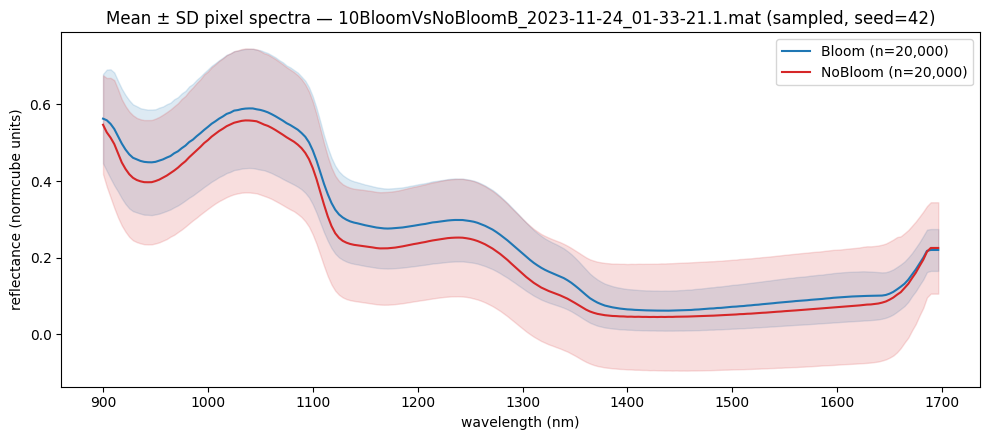

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = {2: "tab:blue", 3: "tab:red"}
for label in (2, 3):
    spectra = X[y == label]
    m, s = spectra.mean(axis=0), spectra.std(axis=0)
    wav = WAVELENGTHS_NM if WAVELENGTHS_NM.size == N_BANDS else np.arange(N_BANDS)
    ax.plot(wav, m, color=colors[label], lw=1.5,
            label=f"{LABEL_NAMES.get(label, label)} (n={spectra.shape[0]:,})")
    ax.fill_between(wav, m - s, m + s, color=colors[label], alpha=0.15)
ax.set_xlabel("wavelength (nm)" if WAVELENGTHS_NM.size == N_BANDS and WAVELENGTHS_NM.max() > 100
              else "band index (lambda shape inconsistent; see §3)")
ax.set_ylabel("reflectance (normcube units)")
ax.set_title(f"Mean ± SD pixel spectra — {MAT_PATH.name} (sampled, seed={SEED})")
ax.legend()
fig.tight_layout()
plt.show()

## 8. Train and evaluate the pixel classifier (sklearn model from the author's map)

The happy-tools CLI default for `happy-scikit-segmentation-build` is `svm`, but the author's
`CLASSIFICATION_MODEL_MAP` (`src/happy/models/sklearn.py`) also exposes `randomforestclassifier`; this demo
uses **RandomForestClassifier(n_estimators=100, n_jobs=-1, fixed seed)** because a default-kernel SVC on
~40k×224 spectra is impractical on a free CPU runtime — a documented adaptation, not a paper parameter.
Split: stratified 70/30 pixel-level train/test (seeded). Reported: accuracy, confusion matrix, and per-class
precision/recall/F1 on the held-out pixels. **Known optimistic bias:** pixels are spatially adjacent
(same berries), so this is a *demonstration* metric, not dataset-level accuracy.

**日本語:** happy-tools のモデルマップから `randomforestclassifier`(推定器 100 本、固定シード)を使用します。
CLI 既定の `svm` は CPU では重いための翻案であり、論文の指定ではありません。層化 70/30 の画素分割で学習・
評価します(空間的に隣接画素を含むため楽観バイアスがあり、論文精度の検証ではありません)。

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

t_fit = time.time()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)

ACC = accuracy_score(y_te, y_pred)
CM = confusion_matrix(y_te, y_pred, labels=[2, 3])
print(f"held-out pixel accuracy: {ACC:.4f}   (train {X_tr.shape}, test {X_te.shape}, "
      f"fit+predict {time.time()-t_fit:.1f}s)")
print("confusion matrix (rows = reference FinalMask, cols = prediction):")
print(CM)
print()
target_names = [LABEL_NAMES.get(2, "2"), LABEL_NAMES.get(3, "3")]
print(classification_report(y_te, y_pred, labels=[2, 3], target_names=target_names, digits=4))

held-out pixel accuracy: 0.9876   (train (28000, 224), test (12000, 224), fit+predict 24.3s)
confusion matrix (rows = reference FinalMask, cols = prediction):
[[5930   70]
 [  79 5921]]

              precision    recall  f1-score   support

       Bloom     0.9869    0.9883    0.9876      6000
     NoBloom     0.9883    0.9868    0.9876      6000

    accuracy                         0.9876     12000
   macro avg     0.9876    0.9876    0.9876     12000
weighted avg     0.9876    0.9876    0.9876     12000



## 9. Full-mask prediction vs reference annotation

The fitted classifier is applied to **every labeled pixel** of the scan (labels 2 and 3 only — background,
unlabeled and white-reference pixels are excluded, mirroring the author pipeline's annotation-driven
inference and `create_prediction_image`/false-color outputs in `segmentation_build.py`). The left map is
the reference `FinalMask`; the right map is the model's prediction for the same pixels.

**日本語:** 学習済み分類器をラベル 2/3 の全画素に適用し、参照マスク(左)と予測マップ(右)を並べて表示します。

predicted 86,961 labeled pixels in 0.5s


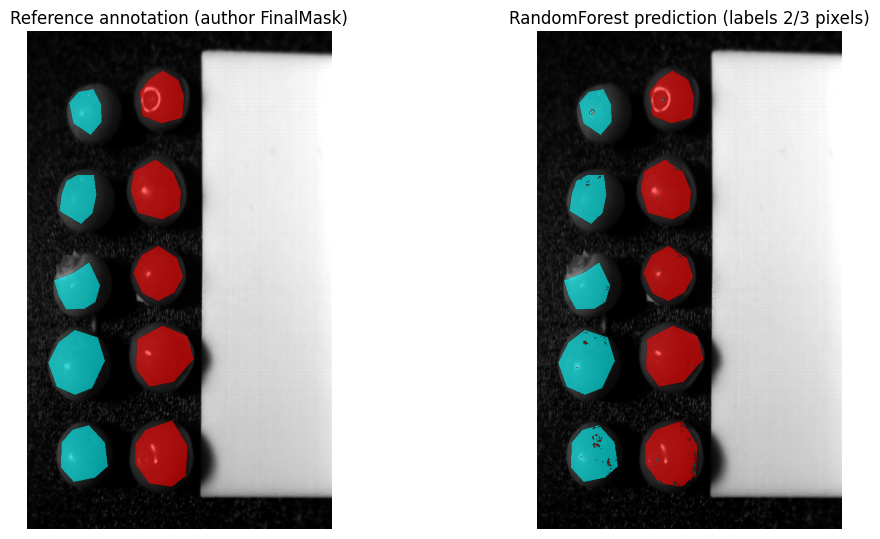

agreement on this scan: bloom pixels 0.9923, no-bloom pixels 0.9912


In [ ]:
labeled_px = np.flatnonzero((mask_flat == 2) | (mask_flat == 3))
t_pred = time.time()
pred_flat = mask_flat.astype(np.uint8).copy()
pred_flat[labeled_px] = rf.predict(X_all[labeled_px])
pred_map = pred_flat.reshape(final_mask.shape)
print(f"predicted {labeled_px.size:,} labeled pixels in {time.time()-t_pred:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, data, title in [
    (axes[0], final_mask, "Reference annotation (author FinalMask)"),
    (axes[1], pred_map, "RandomForest prediction (labels 2/3 pixels)"),
]:
    ax.imshow(img8, cmap="gray")
    ax.imshow(np.ma.masked_where(~(data == 2), data == 2), cmap="cool", alpha=0.6)
    ax.imshow(np.ma.masked_where(~(data == 3), data == 3), cmap="autumn", alpha=0.6)
    ax.set_title(title)
    ax.set_axis_off()
fig.tight_layout()
plt.show()

agree = (pred_map[final_mask == 2] == 2).mean(), (pred_map[final_mask == 3] == 3).mean()
print(f"agreement on this scan: bloom pixels {agree[0]:.4f}, no-bloom pixels {agree[1]:.4f}")

## 10. Results table and CSV export

A small summary of the executed run (metrics are from §8's held-out pixels and §9's scan-level agreement).
The CSV is written to the Colab VM (`/content/bbhsi/`); use the Colab Files panel to download it.

**日本語:** 実行結果の要約表です。CSV は Colab VM の `/content/bbhsi/` に保存され、ファイル パネルから
ダウンロードできます。

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_te, y_pred, labels=[2, 3])
rows = []
for i, label in enumerate((2, 3)):
    rows.append({"class_label": label, "class_name": LABEL_NAMES.get(label, str(label)),
                 "precision": round(float(precision[i]), 4), "recall": round(float(recall[i]), 4),
                 "f1": round(float(f1[i]), 4), "test_pixels": int(support[i])})
rows.append({"class_label": "overall", "class_name": "held-out accuracy",
             "precision": "", "recall": "", "f1": round(float(ACC), 4), "test_pixels": int(y_te.size)})
results = pd.DataFrame(rows)
display(results)
RESULTS_CSV = DATA_DIR / "results_metrics.csv"
results.to_csv(RESULTS_CSV, index=False)
print("saved:", RESULTS_CSV)

,class_label,class_name,precision,recall,f1,test_pixels
0,2,Bloom,0.9869,0.9883,0.9876,6000
1,3,NoBloom,0.9883,0.9868,0.9876,6000
2,overall,held-out accuracy,,,0.9876,12000


saved: /content/bbhsi/results_metrics.csv


## 11. Interpretation and limitations

- **What was executed:** one 1046×640×224 NIR hypercube ('No EW vs. Perfect EW') downloaded and MD5-verified
  from Harvard Dataverse, loaded per the author `MatlabReader` contract, seeded bounded pixel sampling,
  RandomForest pixel classification, held-out metrics, and a full-mask prediction map — all inside this
  Colab runtime. Measured wall times are in the cell outputs above.
- **Scientific scope:** a *partial demonstration* on one scan with the paper's own annotations as ground
  truth. The paper reports no accuracy, so there is no published number to compare against; the §8 metrics
  characterize this demo's protocol only.
- **Not verified by this notebook:** dataset-level results, berry-level (image-level) generalization,
  harvest-method classification (AHB/HHB), the other four scans, any model of the authors' related CASE
  2024 paper. The pixel-level split shares berries between train/test (optimistic); a berry-level split is
  the appropriate next step.
- **Data caveats from the paper's own limitations:** single cultivar (Masena), single orchard, small sample
  (39 fruits / 49 images); `lambda` dimension inconsistency in Table 1 is handled defensively in §3.
- **Reproducibility:** fixed seed 42, pinned Dataverse file ids + MD5, pinned happy-tools commit
  `b4476d01…`. Runtime note: re-running on GPU would change nothing (no GPU code path); free-tier CPU is
  sufficient.

**日本語:** 本ノートブックは 1 枚のハイパースペクトル画像に対する**部分的な実行デモ**です。論文は精度を報告して
いないため比較対象はなく、画素分割には楽観バイアスがあります。ベリー単位の分割、他 4 画像、収穫手法分類は
未検証です。再現条件: シード 42、Dataverse ファイル ID/MD5 固定、happy-tools コミット `b4476d01…` 固定。

## 12. References

1. Faisal S, Thawdar Y, Ooi MP-L, Reutemann P, Fletcher D, Kuang YC, Abeysekera SK. *Proximal near-infrared
   hyperspectral imaging dataset for identifying epicuticular wax loss in Masena blueberries to evaluate
   post-harvest quality.* Data in Brief 62:111946 (2025). doi:10.1016/j.dib.2025.111946. PMC12356377 (CC BY).
2. BB-HSI dataset, Harvard Dataverse doi:10.7910/DVN/ENJYTC, v1 (2025-05-15), CC0 1.0 — files 11382703,
   11382699 (MD5 verified at download).
3. happy-tools (Fletcher D, Reutemann P), MIT License, commit `b4476d01f19533d4e2bedf28bb781c4fb0d150e2` —
   `_matlab_reader.py`, `_simple_selector.py`, `models/sklearn.py`, `console/builders/segmentation_build.py`.
4. Object-Predictions-Exchange (OPEX) format — WaikatoLink2020/objdet-predictions-exchange-format (cited by
   the paper for annotation serialization; not used by this minimal path).